In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
class SalesDataAnalyzer:

    def __init__(self):
        self.data = None
        self.current_plot = None
        print("Sales Data Analyzer initialized!")

    def __del__(self):
        print("Exiting the program... Goodbye!")

    # ==========================
    # Load Dataset
    # ==========================
    def load_data(self, file_path):
        try:
            self.data = pd.read_csv(file_path)
            print("Dataset loaded successfully!")
        except Exception as e:
            print("Error loading file:", e)

    # ==========================
    # Explore Data
    # ==========================
    def explore_data(self):

        if self.data is None:
            print("Load dataset first!")
            return

        while True:

            print("\n== Explore Data ==")
            print("1. Display first 5 rows")
            print("2. Display last 5 rows")
            print("3. Display column names")
            print("4. Display data types")
            print("5. Display basic info")
            print("6. Back")

            choice = input("Enter choice: ")

            if choice == "1":
                print(self.data.head())

            elif choice == "2":
                print(self.data.tail())

            elif choice == "3":
                print(self.data.columns)

            elif choice == "4":
                print(self.data.dtypes)

            elif choice == "5":
                print(self.data.info())

            elif choice == "6":
                break

    # ==========================
    # Missing Values Handling
    # ==========================
    def clean_data(self):

        if self.data is None:
            print("Load dataset first!")
            return

        print("\n== Handle Missing Data ==")
        print("1. Display rows with missing values")
        print("2. Fill missing values with mean")
        print("3. Drop rows with missing values")
        print("4. Replace with custom value")

        choice = input("Enter choice: ")

        if choice == "1":

            missing = self.data[self.data.isnull().any(axis=1)]

            if missing.empty:
                print("No missing values found!")
            else:
                print(missing)

        elif choice == "2":

            numeric_cols = self.data.select_dtypes(
                include=np.number).columns

            self.data[numeric_cols] = (
                self.data[numeric_cols]
                .fillna(self.data[numeric_cols].mean())
            )

            print("Missing values filled with mean")

        elif choice == "3":
            self.data.dropna(inplace=True)
            print("Rows removed")

        elif choice == "4":

            value = input("Enter replacement value: ")
            self.data.fillna(value, inplace=True)

            print("Missing values replaced")

    # ==========================
    # Mathematical Operations
    # ==========================
    def mathematical_operations(self):

        if self.data is None:
            return

        print("\n== Mathematical Operations ==")

        numeric = self.data.select_dtypes(include=np.number)

        print("\nSum")
        print(numeric.sum())

        print("\nMean")
        print(numeric.mean())

        print("\nMax")
        print(numeric.max())

        print("\nMin")
        print(numeric.min())

    # ==========================
    # Search Sort Filter
    # ==========================
    def search_sort_filter(self):

        if self.data is None:
            return

        print("\n1.Search")
        print("2.Sort")
        print("3.Filter")

        ch = input("Choice: ")

        if ch == "1":

            column = input("Column name: ")
            value = input("Search value: ")

            print(self.data[self.data[column].astype(str)
                            == value])

        elif ch == "2":

            column = input("Sort by column: ")

            print(self.data.sort_values(by=column))

        elif ch == "3":

            column = input("Filter column: ")
            value = input("Value: ")

            print(self.data[self.data[column].astype(str)
                            == value])

    # ==========================
    # Statistics
    # ==========================
    def statistical_analysis(self):

        if self.data is None:
            return

        print("\n== Statistical Analysis ==")

        print(self.data.describe())

        numeric = self.data.select_dtypes(include=np.number)

        print("\nStandard Deviation")
        print(numeric.std())

        print("\nVariance")
        print(numeric.var())

        print("\nPercentiles")
        print(numeric.quantile([0.25,0.50,0.75]))

    # ==========================
    # Pivot Table
    # ==========================
    def create_pivot_table(self):

        if self.data is None:
            return

        index = input("Index column: ")
        values = input("Values column: ")

        pivot = pd.pivot_table(
            self.data,
            values=values,
            index=index,
            aggfunc=np.sum
        )

        print("\nPivot Table")
        print(pivot)

    # ==========================
    # Split Data
    # ==========================
    def split_data(self):

        if self.data is None:
            return

        col = input("Split by column: ")

        groups = dict(tuple(self.data.groupby(col)))

        for key, value in groups.items():

            print("\n",key)
            print(value.head())

    # ==========================
    # Visualization
    # ==========================
    def visualize_data(self):

        if self.data is None:
            return

        print("\n== Data Visualization ==")
        print("1.Bar Plot")
        print("2.Line Plot")
        print("3.Scatter Plot")
        print("4.Pie Chart")
        print("5.Histogram")
        print("6.Stack Plot")
        print("7.Box Plot")
        print("8.Heatmap")

        choice = input("Choice: ")

        plt.figure(figsize=(8,5))

        if choice=="1":

            x=input("X-axis column:")
            y=input("Y-axis column:")

            plt.bar(self.data[x],self.data[y])

        elif choice=="2":

            x=input("X-axis:")
            y=input("Y-axis:")

            plt.plot(self.data[x],self.data[y])

        elif choice=="3":

            x=input("X-axis:")
            y=input("Y-axis:")

            plt.scatter(self.data[x],self.data[y])

        elif choice=="4":

            col=input("Column:")

            self.data[col].value_counts().plot(
                kind='pie',
                autopct='%1.1f%%'
            )

        elif choice=="5":

            col=input("Column:")

            plt.hist(self.data[col])

        elif choice=="6":

            x=input("X-axis:")
            y=input("Y-axis:")

            plt.stackplot(
                self.data[x],
                self.data[y]
            )

        elif choice=="7":

            col=input("Column:")
            sns.boxplot(y=self.data[col])

        elif choice=="8":

            sns.heatmap(
                self.data.corr(numeric_only=True),
                annot=True
            )

        plt.title("Sales Visualization")
        if choice in ["1","2","3","6"]:
            plt.legend()
        plt.show()

        self.current_plot = plt

    # ==========================
    # Save Plot
    # ==========================
    def save_plot(self):

        if self.current_plot is None:
            print("Generate plot first!")
            return

        filename=input(
            "Enter file name (example: graph.png): "
        )

        self.current_plot.savefig(filename)

        print("Visualization saved successfully!")
        
        
def main():
    obj=SalesDataAnalyzer()
        
    while True:

        print("\n")
        print("="*55)
        print("Data Analysis & Visualization Program")
        print("="*55)

        print("1.Load Dataset")
        print("2.Explore Data")
        print("3.Perform DataFrame Operations")
        print("4.Handle Missing Data")
        print("5.Generate Statistics")
        print("6.Data Visualization")
        print("7.Save Visualization")
        print("8.Create Pivot Table")
        print("9.Split Data")
        print("10.Search/Sort/Filter")
        print("11.Exit")

        print("="*55)

        choice=input("\nEnter your choice: ")

        if choice=="1":
            print("\n== Load Dataset ==")
            
            path = input("Enter the path of the dataset (CSV file):")
            
            obj.load_data(path)

        elif choice=="2":
            obj.explore_data()

        elif choice=="3":
            obj.mathematical_operations()

        elif choice=="4":
            obj.clean_data()

        elif choice=="5":
            obj.statistical_analysis()

        elif choice=="6":
            obj.visualize_data()

        elif choice=="7":
            obj.save_plot()

        elif choice=="8":
            obj.create_pivot_table()

        elif choice=="9":
            obj.split_data()

        elif choice=="10":
            obj.search_sort_filter()

        elif choice=="11":
            break

        else:
            print("Invalid choice")


Sales Data Analyzer initialized!


Data Analysis & Visualization Program
1.Load Dataset
2.Explore Data
3.Perform DataFrame Operations
4.Handle Missing Data
5.Generate Statistics
6.Data Visualization
7.Save Visualization
8.Create Pivot Table
9.Split Data
10.Search/Sort/Filter
11.Exit



Enter your choice:  1



== Load Dataset ==


Enter the path of the dataset (CSV file): sales.csv


Dataset loaded successfully!


Data Analysis & Visualization Program
1.Load Dataset
2.Explore Data
3.Perform DataFrame Operations
4.Handle Missing Data
5.Generate Statistics
6.Data Visualization
7.Save Visualization
8.Create Pivot Table
9.Split Data
10.Search/Sort/Filter
11.Exit


...


== Statistical Analysis ==
              Sales   Quantity
count     50.000000  50.000000
mean   47560.820000   7.660000
std    23562.921578   4.255177
min    10340.000000   1.000000
25%    29902.500000   4.000000
50%    47110.500000   8.500000
75%    71463.250000  11.000000
max    86867.000000  15.000000

Standard Deviation
Sales       23562.921578
Quantity        4.255177
dtype: float64

Variance
Sales       5.552113e+08
Quantity    1.810653e+01
dtype: float64

Percentiles
         Sales  Quantity
0.25  29902.50       4.0
0.50  47110.50       8.5
0.75  71463.25      11.0


Data Analysis & Visualization Program
1.Load Dataset
2.Explore Data
3.Perform DataFrame Operations
4.Handle Missing Data
5.Generate Statistics
6.Data Visualization
7.Save Visualization
8.Create Pivot Table
9.Split Data
10.Search/Sort/Filter
11.Exit



Enter your choice:  6



== Data Visualization ==
1.Bar Plot
2.Line Plot
3.Scatter Plot
4.Pie Chart
5.Histogram
6.Stack Plot
7.Box Plot
8.Heatmap


Choice:  1
X-axis column: Product
Y-axis column: Sales


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9764\1081680955.py:312: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


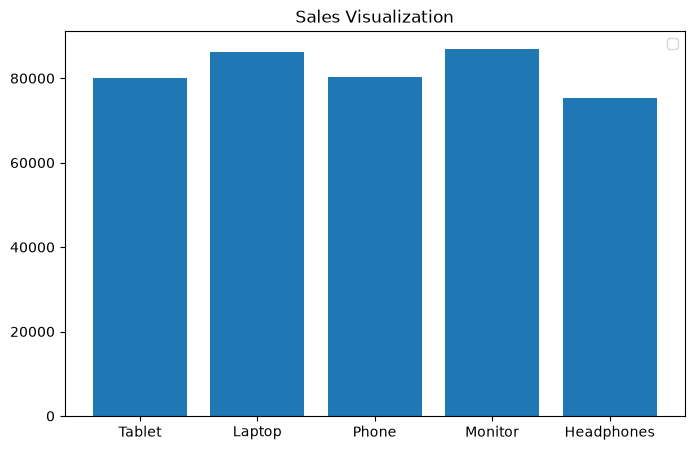



Data Analysis & Visualization Program
1.Load Dataset
2.Explore Data
3.Perform DataFrame Operations
4.Handle Missing Data
5.Generate Statistics
6.Data Visualization
7.Save Visualization
8.Create Pivot Table
9.Split Data
10.Search/Sort/Filter
11.Exit



Enter your choice:  6



== Data Visualization ==
1.Bar Plot
2.Line Plot
3.Scatter Plot
4.Pie Chart
5.Histogram
6.Stack Plot
7.Box Plot
8.Heatmap


Choice:  2
X-axis: Product
Y-axis: Sales


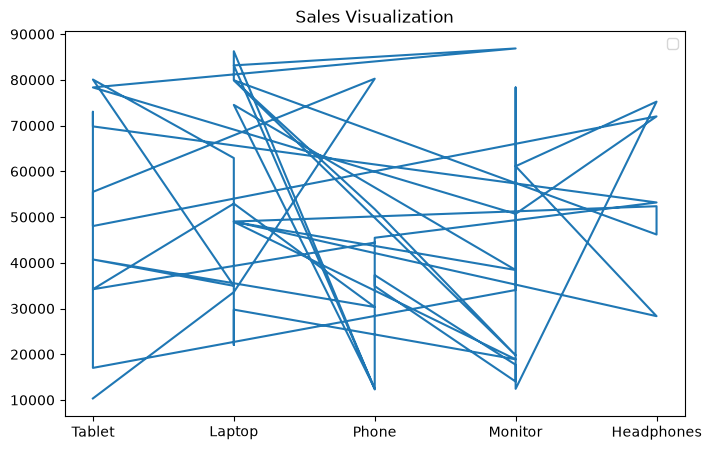



Data Analysis & Visualization Program
1.Load Dataset
2.Explore Data
3.Perform DataFrame Operations
4.Handle Missing Data
5.Generate Statistics
6.Data Visualization
7.Save Visualization
8.Create Pivot Table
9.Split Data
10.Search/Sort/Filter
11.Exit



Enter your choice:  6



== Data Visualization ==
1.Bar Plot
2.Line Plot
3.Scatter Plot
4.Pie Chart
5.Histogram
6.Stack Plot
7.Box Plot
8.Heatmap


Choice:  3
X-axis: Product
Y-axis: Sales


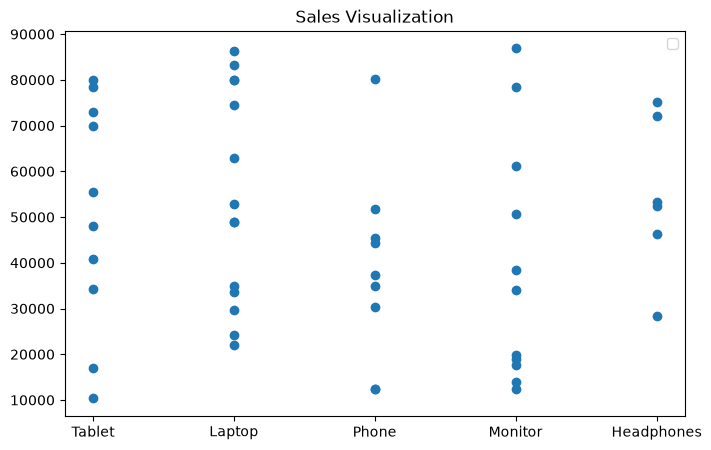



Data Analysis & Visualization Program
1.Load Dataset
2.Explore Data
3.Perform DataFrame Operations
4.Handle Missing Data
5.Generate Statistics
6.Data Visualization
7.Save Visualization
8.Create Pivot Table
9.Split Data
10.Search/Sort/Filter
11.Exit



Enter your choice:  6



== Data Visualization ==
1.Bar Plot
2.Line Plot
3.Scatter Plot
4.Pie Chart
5.Histogram
6.Stack Plot
7.Box Plot
8.Heatmap


Choice:  4
Column: Product


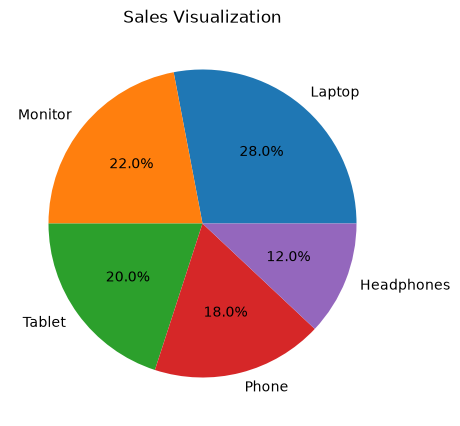



Data Analysis & Visualization Program
1.Load Dataset
2.Explore Data
3.Perform DataFrame Operations
4.Handle Missing Data
5.Generate Statistics
6.Data Visualization
7.Save Visualization
8.Create Pivot Table
9.Split Data
10.Search/Sort/Filter
11.Exit



Enter your choice:  6



== Data Visualization ==
1.Bar Plot
2.Line Plot
3.Scatter Plot
4.Pie Chart
5.Histogram
6.Stack Plot
7.Box Plot
8.Heatmap


Choice:  6
X-axis: Sales
Y-axis: Quantity


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9764\1081680955.py:312: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


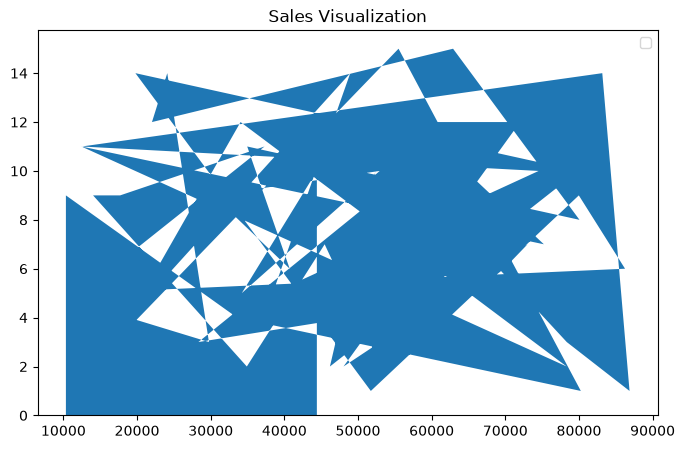



Data Analysis & Visualization Program
1.Load Dataset
2.Explore Data
3.Perform DataFrame Operations
4.Handle Missing Data
5.Generate Statistics
6.Data Visualization
7.Save Visualization
8.Create Pivot Table
9.Split Data
10.Search/Sort/Filter
11.Exit



Enter your choice:  6



== Data Visualization ==
1.Bar Plot
2.Line Plot
3.Scatter Plot
4.Pie Chart
5.Histogram
6.Stack Plot
7.Box Plot
8.Heatmap


Choice:  7
Column: Sales


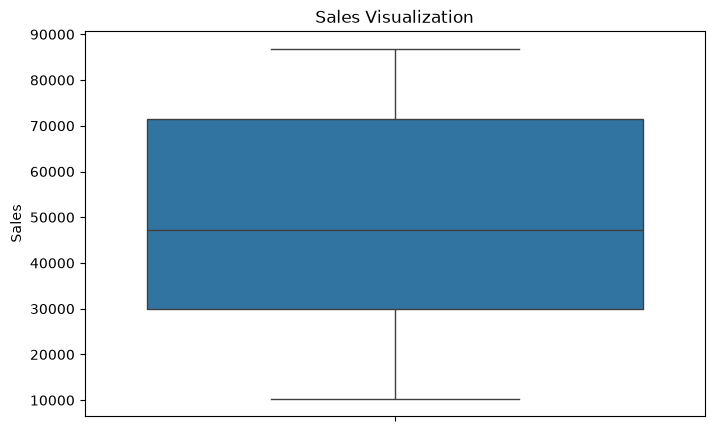



Data Analysis & Visualization Program
1.Load Dataset
2.Explore Data
3.Perform DataFrame Operations
4.Handle Missing Data
5.Generate Statistics
6.Data Visualization
7.Save Visualization
8.Create Pivot Table
9.Split Data
10.Search/Sort/Filter
11.Exit



Enter your choice:  6



== Data Visualization ==
1.Bar Plot
2.Line Plot
3.Scatter Plot
4.Pie Chart
5.Histogram
6.Stack Plot
7.Box Plot
8.Heatmap


Choice:  8


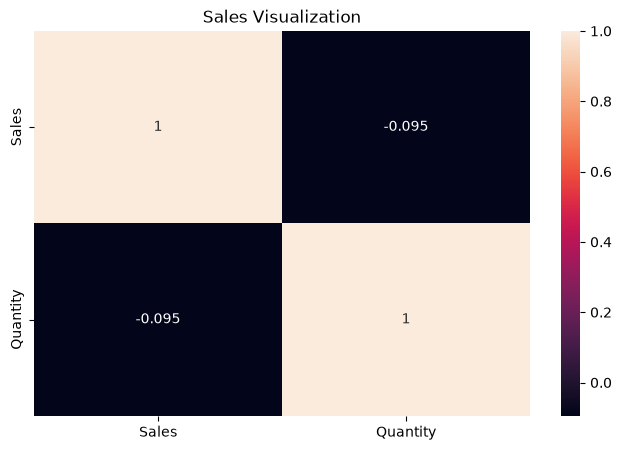



Data Analysis & Visualization Program
1.Load Dataset
2.Explore Data
3.Perform DataFrame Operations
4.Handle Missing Data
5.Generate Statistics
6.Data Visualization
7.Save Visualization
8.Create Pivot Table
9.Split Data
10.Search/Sort/Filter
11.Exit



Enter your choice:  7
Enter file name (example: graph.png):  sales_chart.png


Visualization saved successfully!


Data Analysis & Visualization Program
1.Load Dataset
2.Explore Data
3.Perform DataFrame Operations
4.Handle Missing Data
5.Generate Statistics
6.Data Visualization
7.Save Visualization
8.Create Pivot Table
9.Split Data
10.Search/Sort/Filter
11.Exit



Enter your choice:  8
Index column:  Product
Values column:  Sales



Pivot Table
             Sales
Product           
Headphones  327319
Laptop      762072
Monitor     432335
Phone       349221
Tablet      507094


Data Analysis & Visualization Program
1.Load Dataset
2.Explore Data
3.Perform DataFrame Operations
4.Handle Missing Data
5.Generate Statistics
6.Data Visualization
7.Save Visualization
8.Create Pivot Table
9.Split Data
10.Search/Sort/Filter
11.Exit


...

Choice:  3
Filter column:  Region
Value:  North


          Date     Product  Sales  Quantity Region
1   2026-01-02      Laptop  33583         4  North
2   2026-01-03       Phone  80253         1  North
4   2026-01-05      Tablet  17021         3  North
7   2026-01-08     Monitor  12441        11  North
22  2026-01-23     Monitor  14029         9  North
24  2026-01-25       Phone  45473         7  North
25  2026-01-26  Headphones  53188         2  North
26  2026-01-27      Tablet  69820         6  North
28  2026-01-29      Tablet  48033         2  North
33  2026-02-03      Laptop  83166        14  North
35  2026-02-05      Laptop  74524        10  North
36  2026-02-06     Monitor  38419         5  North
40  2026-02-10      Laptop  24104        14  North


Data Analysis & Visualization Program
1.Load Dataset
2.Explore Data
3.Perform DataFrame Operations
4.Handle Missing Data
5.Generate Statistics
6.Data Visualization
7.Save Visualization
8.Create Pivot Table
9.Split Data
10.Search/Sort/Filter
11.Exit



Enter your choice:  11


Exiting the program... Goodbye!


<Figure size 640x480 with 0 Axes>

In [5]:
main()